In [ ]:

"""
=======================================================
PROJECT 2: Conversion Funnel & Drop-off Analysis
Flipkart Dataset | Python End-to-End Pipeline
=======================================================
Business Problem:
  Map the View → AddToCart → Purchase funnel, identify
  where customers drop off by category, state, and
  payment method, and measure time-to-purchase.
=======================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

In [ ]:
FILE = "Flipcart.xlsx"

customers    = pd.read_excel(FILE, sheet_name="customers",     parse_dates=["JoinDate"])
orders       = pd.read_excel(FILE, sheet_name="orders",        parse_dates=["OrderDate"])
order_details= pd.read_excel(FILE, sheet_name="order_details")
products     = pd.read_excel(FILE, sheet_name="products")
events       = pd.read_excel(FILE, sheet_name="events",        parse_dates=["EventTime"])

print("✅ Data loaded")

✅ Data loaded


In [ ]:
# ═══════════════════════════════════════════════════════
# 1. OVERALL FUNNEL METRICS
# ═══════════════════════════════════════════════════════
funnel_totals = events["EventType"].value_counts()
stage_order   = ["View", "AddToCart", "Purchase"]
funnel = pd.DataFrame({
    "Stage"  : stage_order,
    "Count"  : [funnel_totals.get(s, 0) for s in stage_order]
})
funnel["ConversionRate"] = funnel["Count"] / funnel["Count"].iloc[0] * 100
funnel["DropOff"]        = funnel["Count"].diff().abs().fillna(0)
funnel["DropOffRate"]    = (funnel["DropOff"] / funnel["Count"].shift(1) * 100).fillna(0)

print("\n✅ Overall Funnel:")
print(funnel[["Stage","Count","ConversionRate","DropOffRate"]].to_string(index=False))



✅ Overall Funnel:
    Stage  Count  ConversionRate  DropOffRate
     View   1671      100.000000     0.000000
AddToCart   1639       98.084979     1.915021
 Purchase   1690      101.137044     3.111653


In [ ]:
# ═══════════════════════════════════════════════════════
# 2. FUNNEL BY CATEGORY
# ═══════════════════════════════════════════════════════
# Map events → orders → order_details → products for category
order_cat = (
    order_details
    .merge(orders[["OrderID","CustomerID"]], on="OrderID")
    .merge(products[["ProductID","Category"]], on="ProductID")
    [["CustomerID","Category"]]
    .drop_duplicates()
)


In [ ]:
# Assign each customer their most-purchased category
cat_pref = (
    order_cat.groupby(["CustomerID","Category"])
    .size().reset_index(name="cnt")
    .sort_values("cnt", ascending=False)
    .drop_duplicates("CustomerID")
    [["CustomerID","Category"]]
)

events_with_cat = events.merge(cat_pref, on="CustomerID", how="left")

funnel_cat = (
    events_with_cat
    .groupby(["Category","EventType"])["EventID"]
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["View","AddToCart","Purchase"]:
    if col not in funnel_cat.columns:
        funnel_cat[col] = 0

funnel_cat["View_to_Cart_CR"]    = (funnel_cat["AddToCart"] / funnel_cat["View"].replace(0,np.nan) * 100).round(1)
funnel_cat["Cart_to_Purchase_CR"]= (funnel_cat["Purchase"]  / funnel_cat["AddToCart"].replace(0,np.nan) * 100).round(1)
funnel_cat["Overall_CR"]         = (funnel_cat["Purchase"]  / funnel_cat["View"].replace(0,np.nan) * 100).round(1)

print("\n✅ Funnel by Category:")
print(funnel_cat[["Category","View","AddToCart","Purchase","Overall_CR"]].to_string(index=False))


✅ Funnel by Category:
   Category  View  AddToCart  Purchase  Overall_CR
      Books    85         92        82        96.5
Electronics    40         50        54       135.0
    Fashion    72         93       102       141.7
    Grocery   118        108        99        83.9
       Home   268        298       284       106.0
    Mobiles   406        362       418       103.0
     Sports   675        629       644        95.4


In [ ]:
# ═══════════════════════════════════════════════════════
# 3. FUNNEL BY PAYMENT METHOD
# ═══════════════════════════════════════════════════════
order_with_pay  = orders[["OrderID","CustomerID","PaymentMethod"]]
purch_by_pay    = (
    order_with_pay
    .merge(order_details[["OrderID"]], on="OrderID")
    .groupby("PaymentMethod")["OrderID"].count()
    .reset_index()
    .rename(columns={"OrderID":"Purchase_count"})
)

events_with_pay = events.merge(
    order_with_pay[["CustomerID","PaymentMethod"]].drop_duplicates("CustomerID"),
    on="CustomerID", how="left"
)

funnel_pay = (
    events_with_pay[events_with_pay["PaymentMethod"].notna()]
    .groupby(["PaymentMethod","EventType"])["EventID"]
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["View","AddToCart","Purchase"]:
    if col not in funnel_pay.columns:
        funnel_pay[col] = 0
funnel_pay["CR%"] = (funnel_pay["Purchase"] / funnel_pay["View"].replace(0,np.nan) * 100).round(1)

print("\n✅ Funnel by Payment Method:")
print(funnel_pay[["PaymentMethod","View","AddToCart","Purchase","CR%"]].to_string(index=False))


✅ Funnel by Payment Method:
PaymentMethod  View  AddToCart  Purchase   CR%
          COD   408        399       416 102.0
         Card   401        388       390  97.3
   NetBanking   461        443       439  95.2
          UPI   394        402       438 111.2


In [ ]:
# ═══════════════════════════════════════════════════════
# 4. TIME TO PURCHASE
# ═══════════════════════════════════════════════════════
first_view = (
    events[events["EventType"]=="View"]
    .groupby("CustomerID")["EventTime"].min()
    .reset_index()
    .rename(columns={"EventTime":"FirstView"})
)
first_order = (
    orders
    .groupby("CustomerID")["OrderDate"].min()
    .reset_index()
    .rename(columns={"OrderDate":"FirstOrder"})
)
ttp = first_view.merge(first_order, on="CustomerID", how="inner")
ttp["DaysToPurchase"] = (ttp["FirstOrder"] - ttp["FirstView"]).dt.days
ttp = ttp[ttp["DaysToPurchase"] >= 0]  # remove negatives

print(f"\n✅ Time-to-Purchase: avg={ttp['DaysToPurchase'].mean():.1f} days | "
      f"median={ttp['DaysToPurchase'].median():.1f} days")


✅ Time-to-Purchase: avg=104.8 days | median=73.0 days


In [ ]:
# ═══════════════════════════════════════════════════════
# 5. MONTHLY CONVERSION TREND
# ═══════════════════════════════════════════════════════
events["Month"] = events["EventTime"].dt.to_period("M")
monthly_funnel  = (
    events
    .groupby(["Month","EventType"])["EventID"]
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["View","AddToCart","Purchase"]:
    if col not in monthly_funnel.columns:
        monthly_funnel[col] = 0
monthly_funnel["Overall_CR"] = (monthly_funnel["Purchase"] / monthly_funnel["View"].replace(0,np.nan) * 100).round(2)
monthly_funnel["Month_str"]  = monthly_funnel["Month"].astype(str)

In [ ]:
# ═══════════════════════════════════════════════════════
# 6. FUNNEL BY STATE (top 8)
# ═══════════════════════════════════════════════════════
events_with_state = events.merge(customers[["CustomerID","State"]], on="CustomerID", how="left")
funnel_state = (
    events_with_state
    .groupby(["State","EventType"])["EventID"]
    .count()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["View","AddToCart","Purchase"]:
    if col not in funnel_state.columns:
        funnel_state[col] = 0
funnel_state["CR%"] = (funnel_state["Purchase"] / funnel_state["View"].replace(0,np.nan) * 100).round(1)
funnel_state = funnel_state.sort_values("View", ascending=False).head(8)


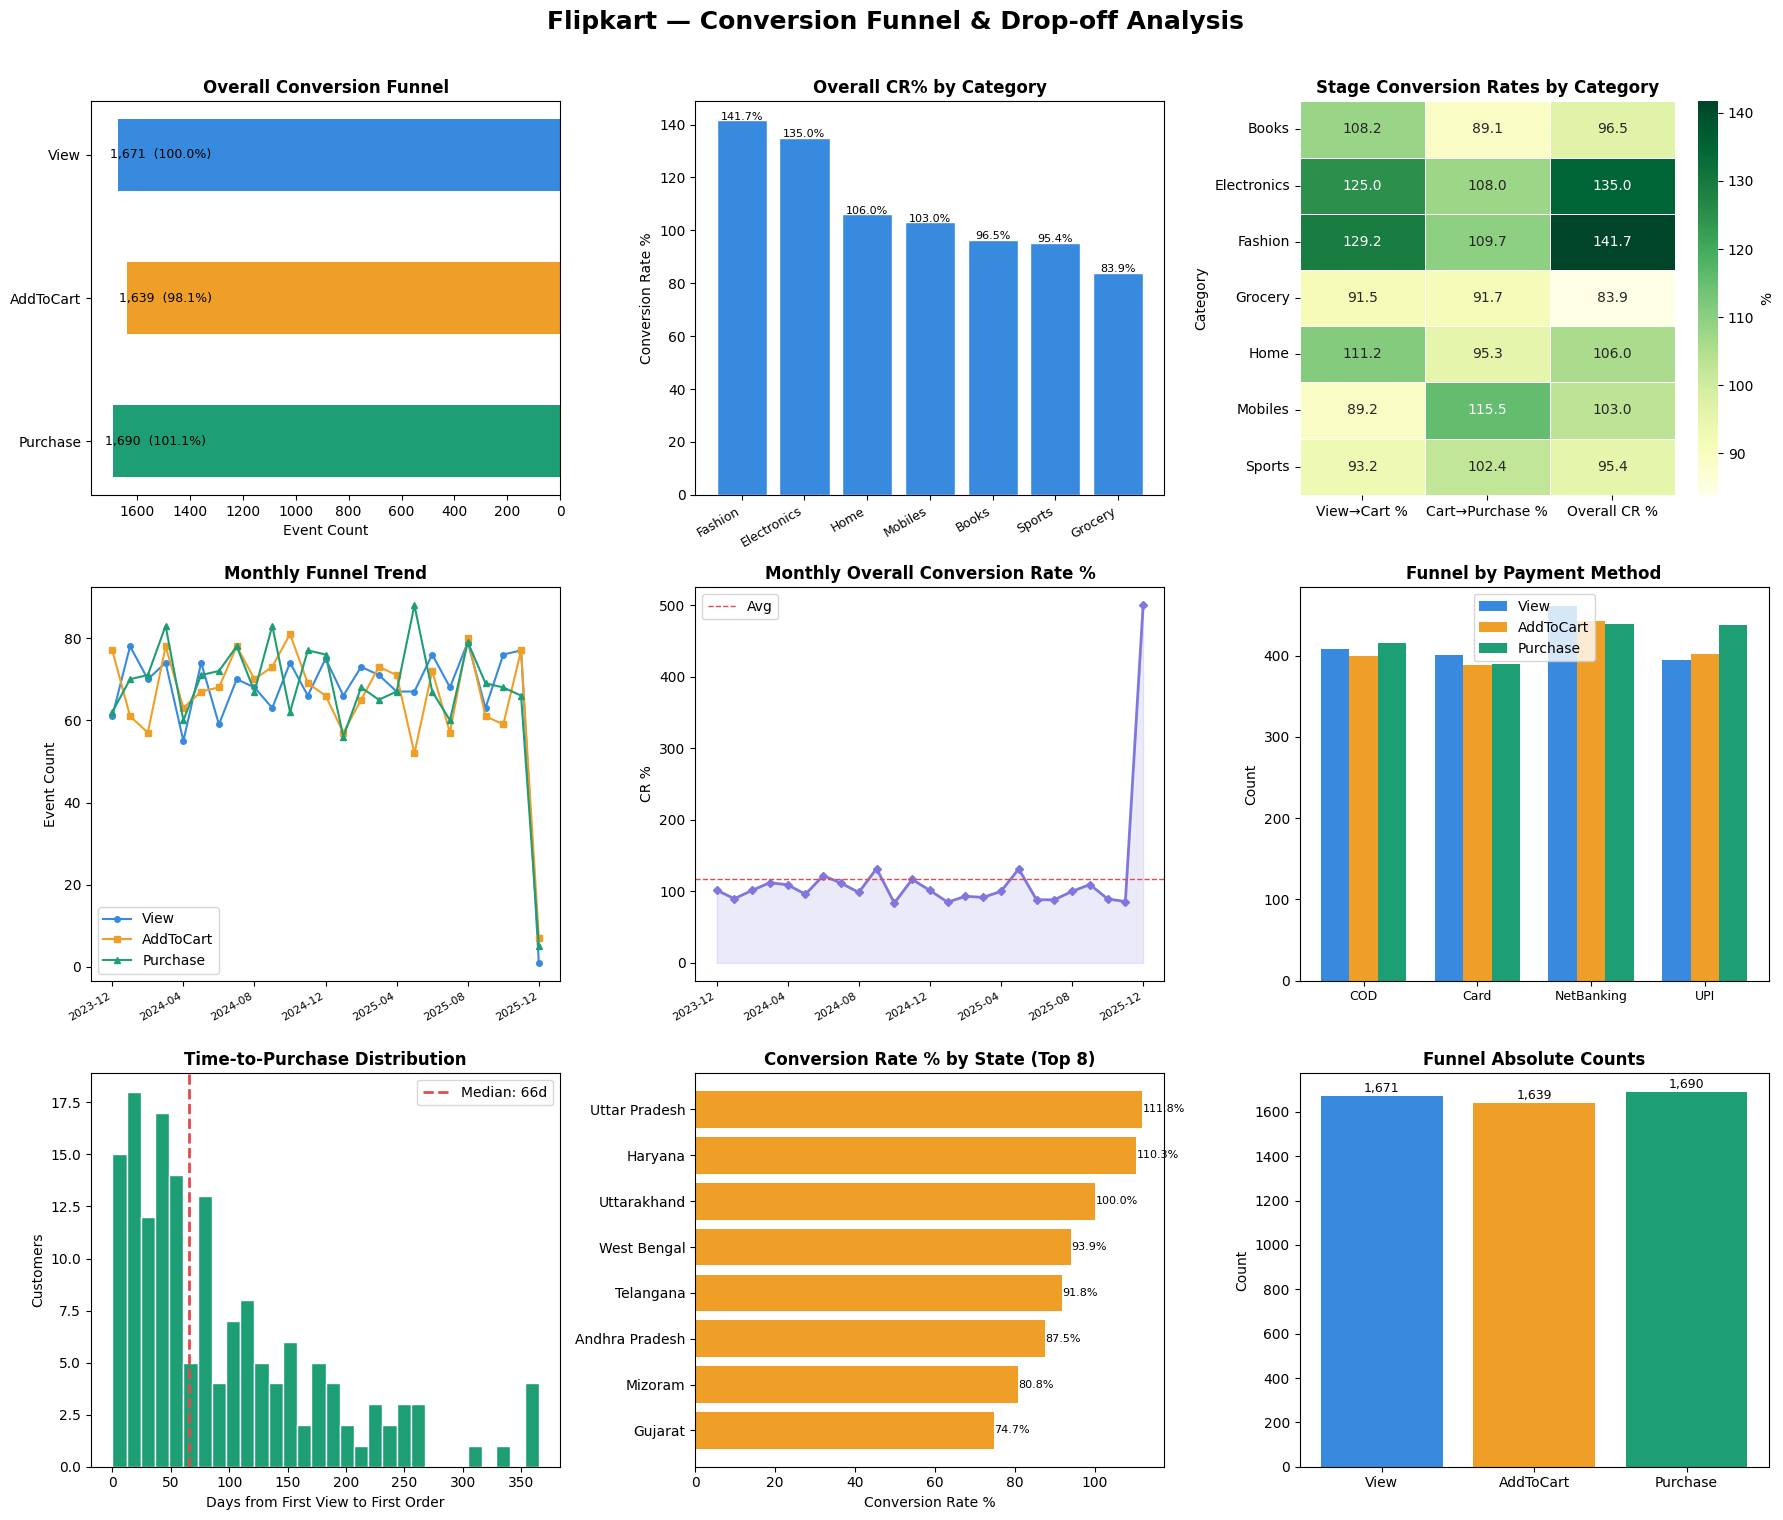

In [ ]:
# ═══════════════════════════════════════════════════════
# 7. VISUALISATIONS
# ═══════════════════════════════════════════════════════
COLORS = {"View":"#378ADD","AddToCart":"#EF9F27","Purchase":"#1D9E75"}
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Flipkart — Conversion Funnel & Drop-off Analysis", fontsize=18, fontweight="bold", y=1.01)

# ── 1. Overall funnel (classic trapezoid style) ───────
ax = axes[0, 0]
bar_colors = [COLORS[s] for s in stage_order]
bars = ax.barh(stage_order[::-1], funnel["Count"][::-1].values, color=bar_colors[::-1], height=0.5)
for i, (bar, row) in enumerate(zip(bars, funnel.iloc[::-1].itertuples())):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{row.Count:,}  ({row.ConversionRate:.1f}%)',
            va="center", fontsize=9)
ax.set_title("Overall Conversion Funnel", fontweight="bold")
ax.set_xlabel("Event Count")
ax.invert_xaxis()

# ── 2. Category-level overall CR ─────────────────────
ax = axes[0, 1]
fc_sorted = funnel_cat.sort_values("Overall_CR", ascending=False)
ax.bar(fc_sorted["Category"], fc_sorted["Overall_CR"],
       color="#378ADD", edgecolor="white")
ax.set_title("Overall CR% by Category", fontweight="bold")
ax.set_ylabel("Conversion Rate %")
ax.set_xticklabels(fc_sorted["Category"], rotation=30, ha="right", fontsize=9)
for bar, val in zip(ax.patches, fc_sorted["Overall_CR"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f"{val:.1f}%", ha="center", fontsize=8)

# ── 3. Stage-wise funnel heatmap by category ─────────
ax = axes[0, 2]
heat_data = funnel_cat.set_index("Category")[["View_to_Cart_CR","Cart_to_Purchase_CR","Overall_CR"]]
heat_data.columns = ["View→Cart %","Cart→Purchase %","Overall CR %"]
sns.heatmap(heat_data, annot=True, fmt=".1f", cmap="YlGn", ax=ax,
            linewidths=0.5, cbar_kws={"label":"%"})
ax.set_title("Stage Conversion Rates by Category", fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# ── 4. Monthly conversion trend ───────────────────────
ax = axes[1, 0]
x = range(len(monthly_funnel))
ax.plot(x, monthly_funnel["View"],       marker="o", ms=4, label="View",       color="#378ADD")
ax.plot(x, monthly_funnel["AddToCart"],  marker="s", ms=4, label="AddToCart",  color="#EF9F27")
ax.plot(x, monthly_funnel["Purchase"],   marker="^", ms=4, label="Purchase",   color="#1D9E75")
step = max(1, len(monthly_funnel)//6)
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(monthly_funnel["Month_str"].iloc[::step], rotation=30, ha="right", fontsize=8)
ax.set_title("Monthly Funnel Trend", fontweight="bold")
ax.set_ylabel("Event Count"); ax.legend()

# ── 5. Monthly CR% line ───────────────────────────────
ax = axes[1, 1]
ax.plot(x, monthly_funnel["Overall_CR"], marker="D", ms=4, color="#7F77DD", lw=2)
ax.fill_between(x, monthly_funnel["Overall_CR"], alpha=0.15, color="#7F77DD")
ax.set_xticks(list(x)[::step])
ax.set_xticklabels(monthly_funnel["Month_str"].iloc[::step], rotation=30, ha="right", fontsize=8)
ax.set_title("Monthly Overall Conversion Rate %", fontweight="bold")
ax.set_ylabel("CR %")
ax.axhline(monthly_funnel["Overall_CR"].mean(), ls="--", color="#E24B4A", lw=1, label="Avg")
ax.legend()

# ── 6. Funnel by Payment Method ───────────────────────
ax = axes[1, 2]
x_pay = np.arange(len(funnel_pay))
w = 0.25
ax.bar(x_pay - w,   funnel_pay["View"],       width=w, label="View",       color="#378ADD")
ax.bar(x_pay,       funnel_pay["AddToCart"],  width=w, label="AddToCart",  color="#EF9F27")
ax.bar(x_pay + w,   funnel_pay["Purchase"],   width=w, label="Purchase",   color="#1D9E75")
ax.set_xticks(x_pay)
ax.set_xticklabels(funnel_pay["PaymentMethod"], rotation=0, fontsize=9)
ax.set_title("Funnel by Payment Method", fontweight="bold")
ax.set_ylabel("Count"); ax.legend()

# ── 7. Time-to-purchase histogram ────────────────────
ax = axes[2, 0]
ttp_clean = ttp[ttp["DaysToPurchase"] <= 365]
ax.hist(ttp_clean["DaysToPurchase"], bins=30, color="#1D9E75", edgecolor="white")
ax.axvline(ttp_clean["DaysToPurchase"].median(), ls="--", color="#E24B4A",
           lw=2, label=f"Median: {ttp_clean['DaysToPurchase'].median():.0f}d")
ax.set_title("Time-to-Purchase Distribution", fontweight="bold")
ax.set_xlabel("Days from First View to First Order")
ax.set_ylabel("Customers"); ax.legend()

# ── 8. CR% by State ───────────────────────────────────
ax = axes[2, 1]
fs_sorted = funnel_state.sort_values("CR%", ascending=True)
ax.barh(fs_sorted["State"], fs_sorted["CR%"], color="#EF9F27")
ax.set_title("Conversion Rate % by State (Top 8)", fontweight="bold")
ax.set_xlabel("Conversion Rate %")
for bar, val in zip(ax.patches, fs_sorted["CR%"]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

# ── 9. Drop-off waterfall ─────────────────────────────
ax = axes[2, 2]
stages  = ["View → Cart drop", "Cart → Purchase drop"]
dropoffs= [
    funnel_totals.get("View",0) - funnel_totals.get("AddToCart",0),
    funnel_totals.get("AddToCart",0) - funnel_totals.get("Purchase",0)
]
converted = [funnel_totals.get("Purchase",0)]
ax.bar(["View","AddToCart","Purchase"],
       [funnel_totals.get(s,0) for s in stage_order],
       color=["#378ADD","#EF9F27","#1D9E75"])
ax.set_title("Funnel Absolute Counts", fontweight="bold")
ax.set_ylabel("Count")
for i, s in enumerate(stage_order):
    v = funnel_totals.get(s, 0)
    ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════
# 8. EXPORT FOR POWER BI
# ═══════════════════════════════════════════════════════
funnel_cat.to_csv("funnel_by_category_powerbi.csv", index=False)
funnel_state.to_csv("funnel_by_state_powerbi.csv", index=False)
monthly_funnel.drop("Month", axis=1).to_csv("funnel_monthly_powerbi.csv", index=False)
print("✅ Power BI exports saved (3 CSV files)")

# ── Summary ───────────────────────────────────────────
print("\n" + "═"*52)
print("  FUNNEL ANALYSIS — SUMMARY REPORT")
print("═"*52)
total_views     = funnel_totals.get("View", 0)
total_carts     = funnel_totals.get("AddToCart", 0)
total_purchases = funnel_totals.get("Purchase", 0)
print(f"  Total Views       : {total_views:>6,}")
print(f"  Total Carts       : {total_carts:>6,}  (CR: {total_carts/total_views*100:.1f}%)")
print(f"  Total Purchases   : {total_purchases:>6,}  (CR: {total_purchases/total_views*100:.1f}%)")
print(f"  Biggest drop-off  : View → Cart  ({(total_views-total_carts)/total_views*100:.1f}% lost)")
print(f"  Top CR category   : {funnel_cat.loc[funnel_cat['Overall_CR'].idxmax(),'Category']}  ({funnel_cat['Overall_CR'].max():.1f}%)")
print(f"  Avg time-to-buy   : {ttp['DaysToPurchase'].mean():.1f} days")
print("═"*52)

✅ Power BI exports saved (3 CSV files)

════════════════════════════════════════════════════
  FUNNEL ANALYSIS — SUMMARY REPORT
════════════════════════════════════════════════════
  Total Views       :  1,671
  Total Carts       :  1,639  (CR: 98.1%)
  Total Purchases   :  1,690  (CR: 101.1%)
  Biggest drop-off  : View → Cart  (1.9% lost)
  Top CR category   : Fashion  (141.7%)
  Avg time-to-buy   : 104.8 days
════════════════════════════════════════════════════
